In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')


In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [6]:
# Load the dataset
df = pd.read_csv('Students Performance Dataset.csv')

print(f"✓ Dataset loaded successfully")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

✓ Dataset loaded successfully
  Shape: 5000 rows × 23 columns

First 5 rows:


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


In [9]:
print("DATASET INFORMATION")


print(f"\nDataset Info:")
df.info()

print(f"\n\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✓ No missing values")

print(f"\n\nDuplicate Rows: {df.duplicated().sum()}")

DATASET INFORMATION

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13

In [10]:
# Cell 4: Explore Column Names

print("ALL COLUMNS IN DATASET")

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique = df[col].nunique()
    print(f"{i:2d}. {col:<30} | dtype: {str(dtype):<10} | unique values: {unique}")

ALL COLUMNS IN DATASET
 1. Student_ID                     | dtype: object     | unique values: 5000
 2. First_Name                     | dtype: object     | unique values: 8
 3. Last_Name                      | dtype: object     | unique values: 6
 4. Email                          | dtype: object     | unique values: 5000
 5. Gender                         | dtype: object     | unique values: 2
 6. Age                            | dtype: int64      | unique values: 7
 7. Department                     | dtype: object     | unique values: 4
 8. Attendance (%)                 | dtype: float64    | unique values: 3182
 9. Midterm_Score                  | dtype: float64    | unique values: 3426
10. Final_Score                    | dtype: float64    | unique values: 3360
11. Assignments_Avg                | dtype: float64    | unique values: 3123
12. Quizzes_Avg                    | dtype: float64    | unique values: 3133
13. Participation_Score            | dtype: float64    | unique valu

GRADE DISTRIBUTION

Grade distribution:
  A:    16 (  0.3%) 
  B:   638 ( 12.8%) ████████████
  C:  2307 ( 46.1%) ██████████████████████████████████████████████
  D:  1760 ( 35.2%) ███████████████████████████████████
  F:   279 (  5.6%) █████


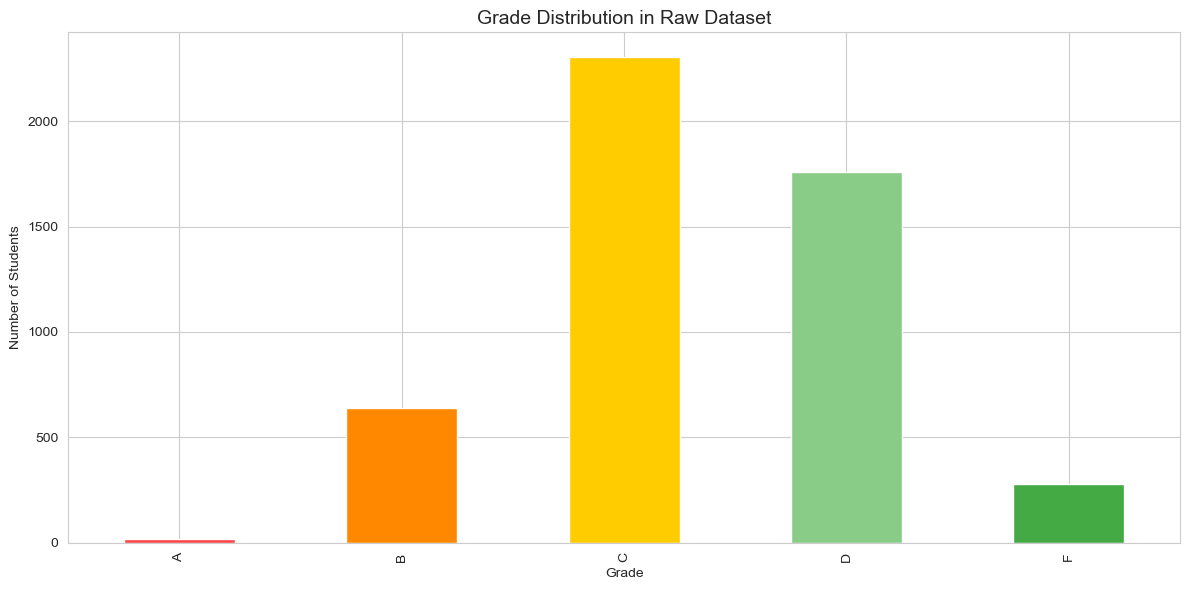

In [11]:
# Cell 5: Grade Distribution (Before Processing)
print("GRADE DISTRIBUTION")

grade_counts = df['Grade'].value_counts().sort_index()
print("\nGrade distribution:")
for grade, count in grade_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct)
    print(f"  {grade}: {count:5d} ({pct:5.1f}%) {bar}")

# Visualize
fig, ax = plt.subplots()
colors = ['#ff4444', '#ff8800', '#ffcc00', '#88cc88', '#44aa44']
grade_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Grade Distribution in Raw Dataset', fontsize=14)
ax.set_xlabel('Grade')
ax.set_ylabel('Number of Students')
plt.tight_layout()
plt.show()

In [12]:
# Cell 6: Drop Unwanted Columns
print("DROPPING UNWANTED COLUMNS")

# Columns to remove
columns_to_drop = [
    'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
    'Internet_Access_at_Home', 'Parent_Education_Level',
    'Family_Income_Level', 'Student_ID'
]

# Keep only columns that exist
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

print(f"Removing {len(columns_to_drop)} columns:")
for col in columns_to_drop:
    print(f"  ✗ {col}")

df = df.drop(columns=columns_to_drop)
print(f"\n✓ Remaining columns: {df.shape[1]}")

DROPPING UNWANTED COLUMNS
Removing 9 columns:
  ✗ First_Name
  ✗ Last_Name
  ✗ Email
  ✗ Gender
  ✗ Age
  ✗ Internet_Access_at_Home
  ✗ Parent_Education_Level
  ✗ Family_Income_Level
  ✗ Student_ID

✓ Remaining columns: 14


In [13]:
# Cell 7: Handle Categorical Variables

print("ENCODING CATEGORICAL VARIABLES")

# Department - One-Hot Encoding
if 'Department' in df.columns:
    dept_counts = df['Department'].value_counts()
    print(f"\nDepartment distribution:")
    for dept, count in dept_counts.items():
        print(f"  {dept}: {count}")
    
    dept_dummies = pd.get_dummies(df['Department'], prefix='Dept')
    df = pd.concat([df, dept_dummies], axis=1)
    df = df.drop(columns=['Department'])
    print(f"✓ Created {dept_dummies.shape[1]} department dummy variables")

# Extracurricular Activities - Binary Encoding
if 'Extracurricular_Activities' in df.columns:
    df['Extracurricular'] = df['Extracurricular_Activities'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['Extracurricular_Activities'])
    print(f"\n✓ Encoded Extracurricular_Activities → Extracurricular (0=No, 1=Yes)")

print(f"\nColumns after encoding: {df.columns.tolist()}")

ENCODING CATEGORICAL VARIABLES

Department distribution:
  Engineering: 1274
  Business: 1264
  CS: 1239
  Mathematics: 1223
✓ Created 4 department dummy variables

✓ Encoded Extracurricular_Activities → Extracurricular (0=No, 1=Yes)

Columns after encoding: ['Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night', 'Dept_Business', 'Dept_CS', 'Dept_Engineering', 'Dept_Mathematics', 'Extracurricular']


In [14]:
# Cell 8: Create Target Variable (Priority Level)
print("CREATING TARGET VARIABLE")

# Map grades to priority levels
grade_to_priority = {
    'A': 0,  # Low priority
    'B': 0,  # Low priority
    'C': 1,  # Medium priority
    'D': 2,  # High priority
    'F': 2   # High priority
}

grade_to_label = {
    'A': 'Low', 'B': 'Low',
    'C': 'Medium', 'D': 'High', 'F': 'High'
}

# Create target columns
df['Priority_Encoded'] = df['Grade'].map(grade_to_priority)
df['Priority_Level'] = df['Grade'].map(grade_to_label)

print("Priority mapping:")
print("  A, B → 0 (Low Priority)")
print("  C    → 1 (Medium Priority)")
print("  D, F → 2 (High Priority)")

# ⚠️ CRITICAL: Drop Grade AND Total_Score
# Total_Score determines Grade → using it is DATA LEAKAGE!
df = df.drop(columns=['Grade', 'Total_Score'])
print(f"\n✓ Dropped columns: Grade, Total_Score (to prevent data leakage)")

# Show target distribution
print(f"\nPriority Distribution:")
for level in [0, 1, 2]:
    count = (df['Priority_Encoded'] == level).sum()
    label = ['Low', 'Medium', 'High'][level]
    pct = count / len(df) * 100
    print(f"  {label} (class {level}): {count} students ({pct:.1f}%)")

CREATING TARGET VARIABLE
Priority mapping:
  A, B → 0 (Low Priority)
  C    → 1 (Medium Priority)
  D, F → 2 (High Priority)

✓ Dropped columns: Grade, Total_Score (to prevent data leakage)

Priority Distribution:
  Low (class 0): 654 students (13.1%)
  Medium (class 1): 2307 students (46.1%)
  High (class 2): 2039 students (40.8%)


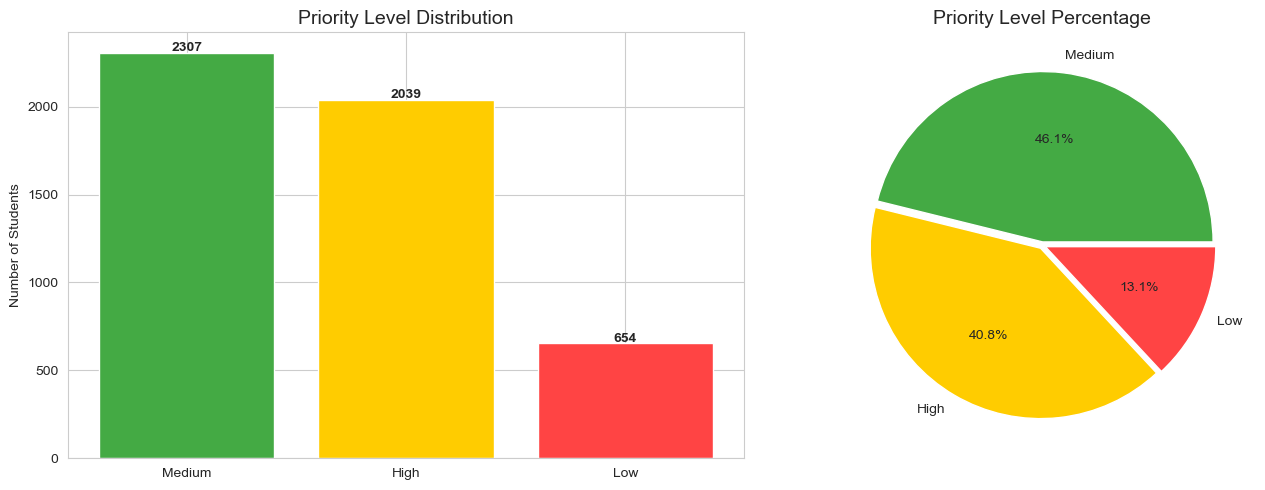

In [15]:
# Cell 9: Visualize Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_target = ['#44aa44', '#ffcc00', '#ff4444']
priority_counts = df['Priority_Level'].value_counts()
axes[0].bar(priority_counts.index, priority_counts.values, color=colors_target)
axes[0].set_title('Priority Level Distribution', fontsize=14)
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(priority_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
priority_pct = df['Priority_Level'].value_counts()
axes[1].pie(priority_pct.values, labels=priority_pct.index, 
            autopct='%1.1f%%', colors=colors_target, explode=(0.02, 0.02, 0.02))
axes[1].set_title('Priority Level Percentage', fontsize=14)

plt.tight_layout()
plt.show()

In [16]:
# Cell 10: Feature Engineering
print("FEATURE ENGINEERING")

# 1. Average exam score
df['Avg_Exam_Score'] = (df['Midterm_Score'] + df['Final_Score']) / 2
print("✓ Created: Avg_Exam_Score")

# 2. Exam improvement (Final - Midterm)
df['Exam_Improvement'] = df['Final_Score'] - df['Midterm_Score']
print("✓ Created: Exam_Improvement (negative = declined)")

# 3. Study-to-sleep ratio
df['Study_Sleep_Ratio'] = df['Study_Hours_per_Week'] / (df['Sleep_Hours_per_Night'] + 0.1)
print("✓ Created: Study_Sleep_Ratio")

# 4. Low score counter (scores below 50)
score_cols = ['Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg']
df['Low_Score_Count'] = sum((df[col] < 50).astype(int) for col in score_cols)
print("✓ Created: Low_Score_Count (count of scores < 50)")

# 5. Overall average across all assessments
all_assessments = ['Midterm_Score', 'Final_Score', 'Assignments_Avg', 
                   'Quizzes_Avg', 'Participation_Score', 'Projects_Score']
df['Overall_Avg_Score'] = df[all_assessments].mean(axis=1)
print("✓ Created: Overall_Avg_Score")

# 6. Performance inconsistency (std of scores - higher = more variable)
df['Score_Variability'] = df[all_assessments].std(axis=1)
print("✓ Created: Score_Variability")

# 7. Attendance efficiency
df['Attendance_Efficiency'] = df['Overall_Avg_Score'] / (df['Attendance (%)'] / 100)
print("✓ Created: Attendance_Efficiency")

print(f"\n✓ Total features after engineering: {df.shape[1]}")

FEATURE ENGINEERING
✓ Created: Avg_Exam_Score
✓ Created: Exam_Improvement (negative = declined)
✓ Created: Study_Sleep_Ratio
✓ Created: Low_Score_Count (count of scores < 50)
✓ Created: Overall_Avg_Score
✓ Created: Score_Variability
✓ Created: Attendance_Efficiency

✓ Total features after engineering: 24


FEATURE CORRELATIONS WITH PRIORITY

Top features correlated with High Priority (at-risk students):
(Negative correlation = protective, Positive = risk factor)
--------------------------------------------------
  Overall_Avg_Score              -0.739 ▼ PROTECTIVE ████████████████████████████████████
  Avg_Exam_Score                 -0.571 ▼ PROTECTIVE ████████████████████████████
  Projects_Score                 -0.532 ▼ PROTECTIVE ██████████████████████████
  Final_Score                    -0.527 ▼ PROTECTIVE ██████████████████████████
  Attendance_Efficiency          -0.361 ▼ PROTECTIVE ██████████████████
  Assignments_Avg                -0.291 ▼ PROTECTIVE ██████████████
  Midterm_Score                  -0.281 ▼ PROTECTIVE ██████████████
  Quizzes_Avg                    -0.175 ▼ PROTECTIVE ████████
  Participation_Score            -0.171 ▼ PROTECTIVE ████████
  Exam_Improvement               -0.168 ▼ PROTECTIVE ████████
  Sleep_Hours_per_Night          -0.016 ▼ PROTECTIVE 
  Stress_L

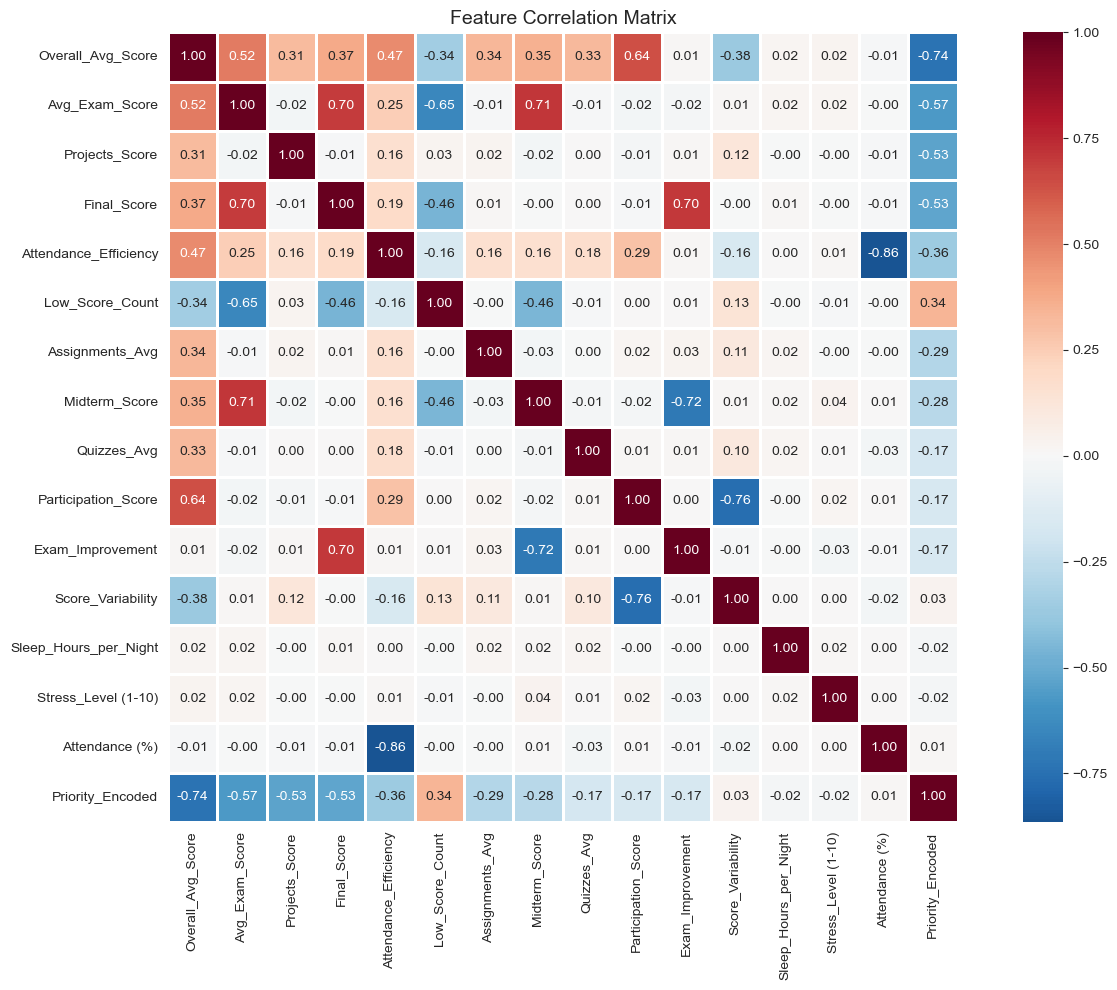

In [17]:
# Cell 11: Correlation Analysis
print("FEATURE CORRELATIONS WITH PRIORITY")


# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ['Priority_Encoded']]

# Correlation with target
correlations = df[numeric_cols].corrwith(df['Priority_Encoded']).sort_values()

print("\nTop features correlated with High Priority (at-risk students):")
print("(Negative correlation = protective, Positive = risk factor)")
print("-"*50)
for col, corr in correlations.items():
    direction = "▲ RISK" if corr > 0 else "▼ PROTECTIVE"
    bar = '█' * int(abs(corr) * 50)
    print(f"  {col:<30} {corr:+.3f} {direction} {bar}")

# Heatmap
plt.figure(figsize=(14, 10))
top_features = correlations.abs().nlargest(15).index.tolist()
corr_matrix = df[top_features + ['Priority_Encoded']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Cell 12: Select Final Features

print("FEATURE SELECTION")

# Exclude target-related columns
exclude_cols = ['Priority_Encoded', 'Priority_Level']

# Get all numeric features
feature_cols = [col for col in df.columns 
                if col not in exclude_cols 
                and df[col].dtype in ['int64', 'float64', 'int32', 'uint8']]

print(f"\nSelected {len(feature_cols)} features for ML model:\n")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Separate features and target
X = df[feature_cols].copy()
y = df['Priority_Encoded'].values
y_labels = df['Priority_Level'].values

print(f"\n✓ Features (X): {X.shape}")
print(f"✓ Target (y): {y.shape}")

FEATURE SELECTION

Selected 18 features for ML model:

   1. Attendance (%)
   2. Midterm_Score
   3. Final_Score
   4. Assignments_Avg
   5. Quizzes_Avg
   6. Participation_Score
   7. Projects_Score
   8. Study_Hours_per_Week
   9. Stress_Level (1-10)
  10. Sleep_Hours_per_Night
  11. Extracurricular
  12. Avg_Exam_Score
  13. Exam_Improvement
  14. Study_Sleep_Ratio
  15. Low_Score_Count
  16. Overall_Avg_Score
  17. Score_Variability
  18. Attendance_Efficiency

✓ Features (X): (5000, 18)
✓ Target (y): (5000,)


In [19]:
# Cell 13: Train/Test Split (80/20 = 4000/1000)
print("TRAIN/TEST SPLIT")

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,      # For reproducibility
    stratify=y            # Keep same class proportions
)

print(f"✓ Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"✓ Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Show class distribution in each split
print(f"\nClass distribution:")
for name, y_set in [("Training", y_train), ("Test", y_test)]:
    dist = np.bincount(y_set)
    pct_low = dist[0]/len(y_set)*100
    pct_med = dist[1]/len(y_set)*100
    pct_high = dist[2]/len(y_set)*100
    print(f"  {name}: Low={dist[0]} ({pct_low:.1f}%), Medium={dist[1]} ({pct_med:.1f}%), High={dist[2]} ({pct_high:.1f}%)")

TRAIN/TEST SPLIT
✓ Training set: 4000 samples (80%)
✓ Test set:     1000 samples (20%)

Class distribution:
  Training: Low=523 (13.1%), Medium=1846 (46.2%), High=1631 (40.8%)
  Test: Low=131 (13.1%), Medium=461 (46.1%), High=408 (40.8%)


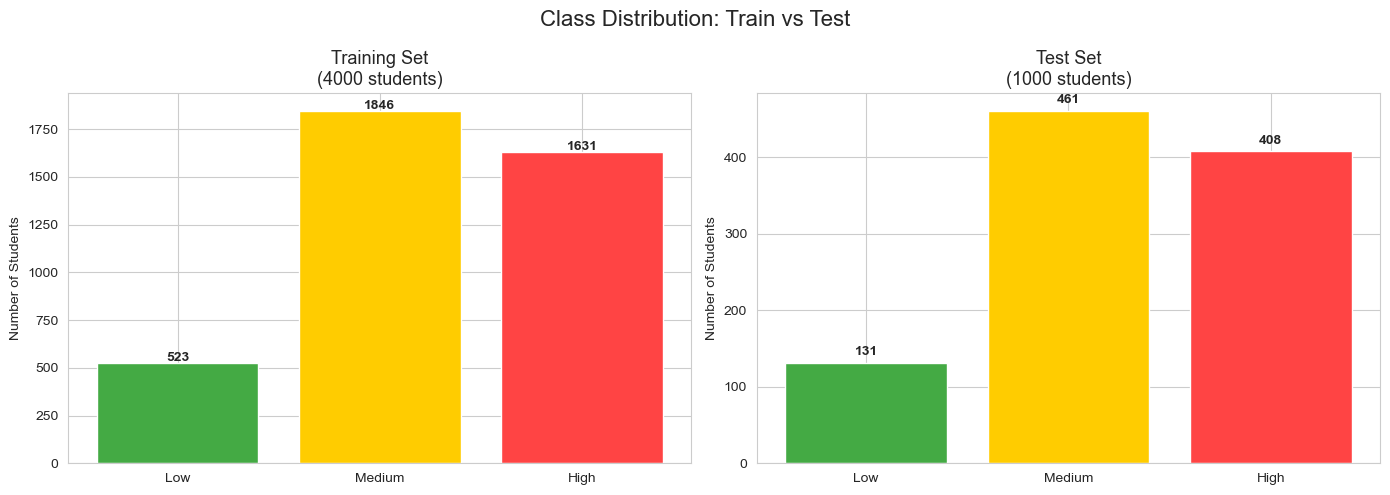

In [20]:
# Cell 14: Visualize Train/Test Split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, y_set) in enumerate([("Training Set", y_train), ("Test Set", y_test)]):
    labels = ['Low', 'Medium', 'High']
    counts = np.bincount(y_set)
    colors_bar = ['#44aa44', '#ffcc00', '#ff4444']
    
    axes[idx].bar(labels, counts, color=colors_bar)
    axes[idx].set_title(f'{name}\n({len(y_set)} students)', fontsize=13)
    axes[idx].set_ylabel('Number of Students')
    for i, v in enumerate(counts):
        axes[idx].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Train vs Test', fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
# Cell 15: Feature Scaling
print("FEATURE SCALING")

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"  Training mean ≈ {X_train_scaled.mean():.6f} (should be ~0)")
print(f"  Training std  ≈ {X_train_scaled.std():.6f} (should be ~1)")

# Show sample of scaled data
print(f"\nSample of scaled training data (first 3 rows, first 5 features):")
scaled_sample = pd.DataFrame(X_train_scaled[:3, :5], 
                              columns=feature_cols[:5])
scaled_sample

FEATURE SCALING
✓ Features scaled using StandardScaler
  Training mean ≈ -0.000000 (should be ~0)
  Training std  ≈ 1.000000 (should be ~1)

Sample of scaled training data (first 3 rows, first 5 features):


,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg
0,1.670407,1.290372,-1.224464,-0.866946,-0.141111
1,0.618127,1.207558,-0.253999,0.899403,1.196390
2,0.214208,-0.929500,-1.536837,-0.286038,0.392503


CLASS WEIGHTS COMPUTATION
Class weights (for handling imbalance):
  Low (class 0): weight=2.5494 (523 samples)
  Medium (class 1): weight=0.7223 (1846 samples)
  High (class 2): weight=0.8175 (1631 samples)


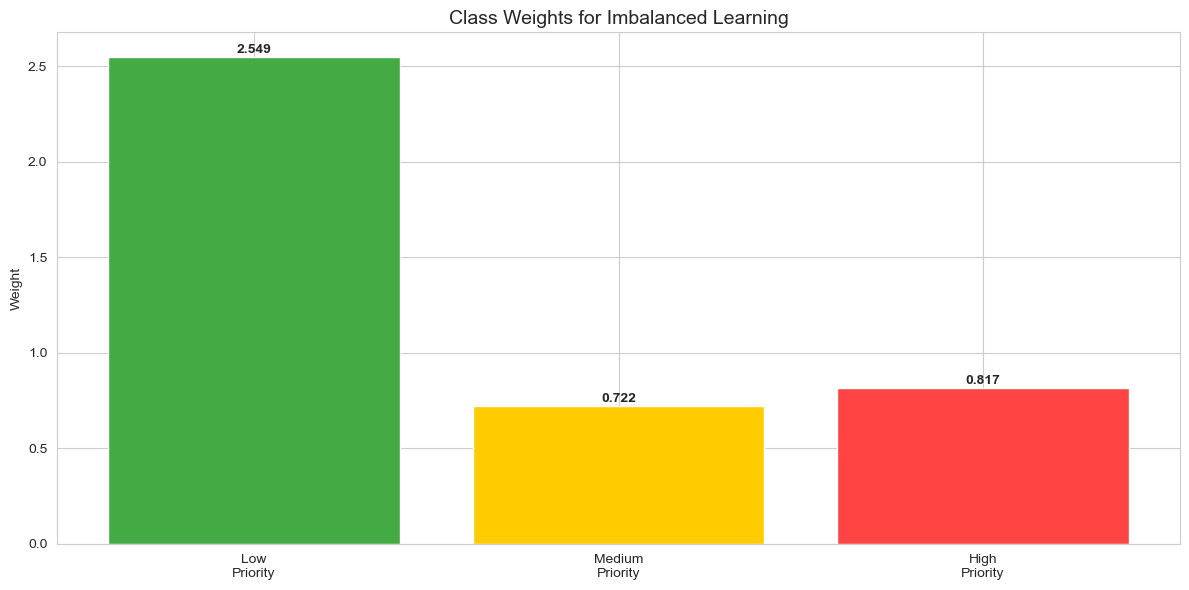

In [22]:
# Cell 16: Compute Class Weights
print("CLASS WEIGHTS COMPUTATION")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],  # Low priority
    1: class_weights[1],  # Medium priority
    2: class_weights[2]   # High priority
}

print("Class weights (for handling imbalance):")
for k, v in class_weight_dict.items():
    label = ['Low', 'Medium', 'High'][k]
    samples = np.bincount(y_train)[k]
    print(f"  {label} (class {k}): weight={v:.4f} ({samples} samples)")

# Visualize weights
fig, ax = plt.subplots()
labels = ['Low\nPriority', 'Medium\nPriority', 'High\nPriority']
ax.bar(labels, [class_weight_dict[i] for i in range(3)], 
       color=['#44aa44', '#ffcc00', '#ff4444'])
ax.set_title('Class Weights for Imbalanced Learning', fontsize=14)
ax.set_ylabel('Weight')
for i, v in enumerate([class_weight_dict[i] for i in range(3)]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Cell 17: Final Dataset Summary
print("FINAL DATASET SUMMARY")

print(f"""
╔══════════════════════════════════════════════════════╗
║           PREPROCESSING SUMMARY                      ║
╠══════════════════════════════════════════════════════╣
║ Original samples:     {len(df):<5}                        ║
║ Features selected:    {len(feature_cols):<5}                        ║
║ Target classes:       3 (Low, Medium, High)          ║
║                                                      ║
║ Training set:         {X_train_scaled.shape[0]:<5} samples             ║
║ Test set:             {X_test_scaled.shape[0]:<5} samples             ║
║                                                      ║
║ Class 0 (Low):        {np.bincount(y_train)[0]:<5} training samples     ║
║ Class 1 (Medium):     {np.bincount(y_train)[1]:<5} training samples     ║
║ Class 2 (High):       {np.bincount(y_train)[2]:<5} training samples     ║
╚══════════════════════════════════════════════════════╝
""")

FINAL DATASET SUMMARY

╔══════════════════════════════════════════════════════╗
║           PREPROCESSING SUMMARY                      ║
╠══════════════════════════════════════════════════════╣
║ Original samples:     5000                         ║
║ Features selected:    18                           ║
║ Target classes:       3 (Low, Medium, High)          ║
║                                                      ║
║ Training set:         4000  samples             ║
║ Test set:             1000  samples             ║
║                                                      ║
║ Class 0 (Low):        523   training samples     ║
║ Class 1 (Medium):     1846  training samples     ║
║ Class 2 (High):       1631  training samples     ║
╚══════════════════════════════════════════════════════╝



In [24]:
print("="*70)
print("SAVING PROCESSED DATA & ARTIFACTS")
print("="*70)

# Create output directories
os.makedirs('preprocessed_data', exist_ok=True)
os.makedirs('model_artifacts', exist_ok=True)

# Save as CSV (for inspection)
train_df = pd.DataFrame(X_train, columns=feature_cols)
train_df['Priority'] = y_train
train_df.to_csv('preprocessed_data/train_data.csv', index=False)
print("✓ Saved: preprocessed_data/train_data.csv")

test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df['Priority'] = y_test
test_df.to_csv('preprocessed_data/test_data.csv', index=False)
print("✓ Saved: preprocessed_data/test_data.csv")

# Save as NumPy arrays (for ML training)
np.save('preprocessed_data/X_train.npy', X_train_scaled)
np.save('preprocessed_data/X_test.npy', X_test_scaled)
np.save('preprocessed_data/y_train.npy', y_train)
np.save('preprocessed_data/y_test.npy', y_test)
print("✓ Saved: NumPy arrays (X_train, X_test, y_train, y_test)")

# Save model artifacts
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
print("✓ Saved: model_artifacts/scaler.pkl")

joblib.dump(feature_cols, 'model_artifacts/feature_columns.pkl')
print("✓ Saved: model_artifacts/feature_columns.pkl")

joblib.dump(class_weight_dict, 'model_artifacts/class_weights.pkl')
print("✓ Saved: model_artifacts/class_weights.pkl")

# Save metadata
metadata = {
    'n_samples': len(df),
    'n_features': len(feature_cols),
    'features': feature_cols,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'class_weights': {str(k): float(v) for k, v in class_weight_dict.items()},
    'class_distribution_train': np.bincount(y_train).tolist(),
    'class_distribution_test': np.bincount(y_test).tolist(),
    'priority_mapping': {
        '0': 'Low Priority (Grade A, B)',
        '1': 'Medium Priority (Grade C)',
        '2': 'High Priority (Grade D, F)'
    }
}

with open('model_artifacts/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("✓ Saved: model_artifacts/metadata.json")

print(f"\n{'='*70}")
print("PREPROCESSING COMPLETE! ✅")
print(f"{'='*70}")
print(f"\nOutput files:")
print(f"  preprocessed_data/")
print(f"    ├── train_data.csv")
print(f"    ├── test_data.csv")
print(f"    ├── X_train.npy")
print(f"    ├── X_test.npy")
print(f"    ├── y_train.npy")
print(f"    └── y_test.npy")
print(f"  model_artifacts/")
print(f"    ├── scaler.pkl")
print(f"    ├── feature_columns.pkl")
print(f"    ├── class_weights.pkl")
print(f"    └── metadata.json")

SAVING PROCESSED DATA & ARTIFACTS
✓ Saved: preprocessed_data/train_data.csv
✓ Saved: preprocessed_data/test_data.csv
✓ Saved: NumPy arrays (X_train, X_test, y_train, y_test)
✓ Saved: model_artifacts/scaler.pkl
✓ Saved: model_artifacts/feature_columns.pkl
✓ Saved: model_artifacts/class_weights.pkl
✓ Saved: model_artifacts/metadata.json

PREPROCESSING COMPLETE! ✅

Output files:
  preprocessed_data/
    ├── train_data.csv
    ├── test_data.csv
    ├── X_train.npy
    ├── X_test.npy
    ├── y_train.npy
    └── y_test.npy
  model_artifacts/
    ├── scaler.pkl
    ├── feature_columns.pkl
    ├── class_weights.pkl
    └── metadata.json
